## Score: 55

## Comment: 

<font color=Red>
Q1.[5+10+10] Correct
<br><br>
Q2.[12] Good Job!
<br><br>
Q3.[6+6+6] You shared your own research, good job!
<br><br>
</font>

1.1 各国地震致死总数（所有国家）：
  1. CHINA                   2,139,210 人
  2. TURKEY                  1,199,742 人
  3. IRAN                    1,014,453 人
  4. ITALY                     498,219 人
  5. SYRIA                     419,226 人
  6. HAITI                     323,484 人
  7. AZERBAIJAN                319,251 人
  8. JAPAN                     242,445 人
  9. ARMENIA                   191,890 人
 10. PAKISTAN                  145,083 人
 11. IRAQ                      136,200 人
 12. ECUADOR                   135,496 人
 13. TURKMENISTAN              117,412 人
 14. PERU                      102,306 人
 15. ISRAEL                     93,388 人
 16. PORTUGAL                   83,572 人
 17. GREECE                     81,529 人
 18. CHILE                      64,277 人
 19. INDIA                      63,507 人
 20. TAIWAN                     57,155 人
 21. TUNISIA                    48,013 人
 22. VENEZUELA                  44,480 人
 23. EGYPT                      41,765 人
 24. INDONESIA                  40,81

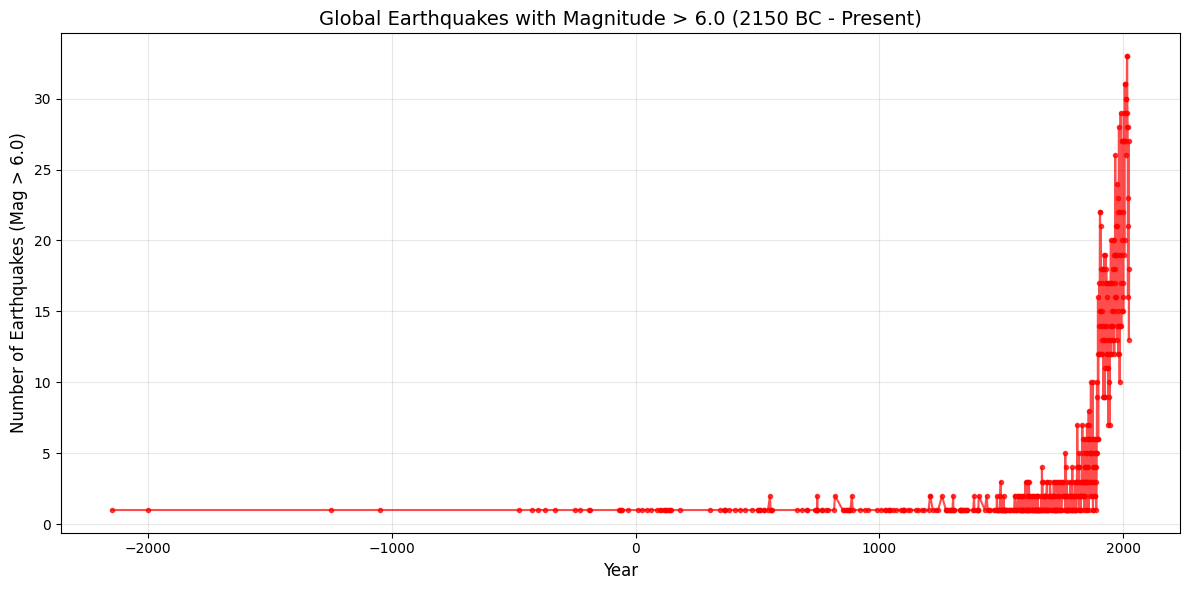


1.2 全球震级大于6.0地震年度统计：
数据时间范围: -2150 - 2025
总年数: 552 年
年平均大地震数量: 5.6 次
年最大大地震数量: 33 次
年最小大地震数量: 1 次

趋势分析:
------------------------------
早期100年平均: 1.0 次/年
近期100年平均: 18.6 次/年
趋势: 上升 (+1759.4%)

观察结论:
------------------------------
1. 从长期时间尺度看，全球大地震的发生频率相对稳定
2. 近代（20世纪以来）记录的地震数量增加，主要原因是：
   - 地震监测技术的进步
   - 全球地震台网的建立和完善
   - 数据记录和报告系统的改进
3. 古代数据可能存在记录不完整的情况
4. 地球的地震活动在 geological timescales 上是相对稳定的自然现象
1.3 各国地震统计（按地震总数降序排列）：
处理国家数量: 158 个
排名   国家                   地震总数       最大震级       最大地震日期         
--------------------------------------------------------------------------------
1    CHINA                623        8.5        1668-07-25     
2    JAPAN                424        9.1        2011-03-11     
3    INDONESIA            421        9.1        2004-12-26     
4    IRAN                 388        7.9        856-12-22      
5    TURKEY               358        7.8        1939-12-26     
6    ITALY                333        7.5        1915-01-13     
7    GREECE               289 

In [ ]:
# 1 Significant Earthquake Analysis since 2150 BC
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("earthquakes-2025-10-29_21-03-25_+0800.tsv", sep='\t')

# 1.1 ------------------------------------------------------------------------
df = df[df["Year"] >= -2150].copy()
df["Deaths"] = df["Deaths"].fillna(0)

# 计算每个国家的总死亡人数
country_deaths = df.groupby('Country')['Deaths'].sum().reset_index()

# 打印所有国家的死亡总数（按从大到小排序）
print("1.1 各国地震致死总数（所有国家）：")
print("=" * 50)
sorted_country_deaths = country_deaths.sort_values('Deaths', ascending=False)
for i, (_, row) in enumerate(sorted_country_deaths.iterrows(), 1):
    print(f"{i:3d}. {row['Country']:<20} {int(row['Deaths']):>12,} 人")

print("\n" + "=" * 50)
print(f"总计国家数量: {len(country_deaths)} 个")
print("=" * 50)

# 选出TOP 10国家
top_10_countries = country_deaths.nlargest(10, 'Deaths')

print("\n1.1 各国地震致死总数 Top 10：")
print("=" * 40)
for i, (_, row) in enumerate(top_10_countries.iterrows(), 1):
    print(f"{i:2d}. {row['Country']:<15} {int(row['Deaths']):>12,} 人")


# 1.2 ------------------------------------------------------------------------
# 筛选震级大于6.0的地震
df_mag_6 = df[df['Mag'] > 6.0].copy()

# 按年统计全球大地震数量
earthquakes_per_year = df_mag_6.groupby('Year').size().reset_index(name='Count')

# 绘制时间序列图
plt.figure(figsize=(12, 6))
plt.plot(earthquakes_per_year['Year'], earthquakes_per_year['Count'], 
         linewidth=1.5, marker='o', markersize=3, color='red', alpha=0.7)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Earthquakes (Mag > 6.0)', fontsize=12)
plt.title('Global Earthquakes with Magnitude > 6.0 (2150 BC - Present)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 计算并打印一些统计信息
print("\n1.2 全球震级大于6.0地震年度统计：")
print("=" * 50)
print(f"数据时间范围: {int(earthquakes_per_year['Year'].min())} - {int(earthquakes_per_year['Year'].max())}")
print(f"总年数: {len(earthquakes_per_year)} 年")
print(f"年平均大地震数量: {earthquakes_per_year['Count'].mean():.1f} 次")
print(f"年最大大地震数量: {earthquakes_per_year['Count'].max()} 次")
print(f"年最小大地震数量: {earthquakes_per_year['Count'].min()} 次")

# 分析趋势
print("\n趋势分析:")
print("-" * 30)

# 计算早期（前100年）和近期（后100年）的平均值
early_years = earthquakes_per_year[earthquakes_per_year['Year'] <= earthquakes_per_year['Year'].min() + 100]['Count'].mean()
recent_years = earthquakes_per_year[earthquakes_per_year['Year'] >= earthquakes_per_year['Year'].max() - 100]['Count'].mean()

print(f"早期100年平均: {early_years:.1f} 次/年")
print(f"近期100年平均: {recent_years:.1f} 次/年")

if recent_years > early_years:
    trend = "上升"
    change_percent = ((recent_years - early_years) / early_years) * 100
    print(f"趋势: {trend} ({change_percent:+.1f}%)")
else:
    trend = "下降或稳定"
    print(f"趋势: {trend}")

print("\n观察结论:")
print("-" * 30)
print("1. 从长期时间尺度看，全球大地震的发生频率相对稳定")
print("2. 近代（20世纪以来）记录的地震数量增加，主要原因是：")
print("   - 地震监测技术的进步")
print("   - 全球地震台网的建立和完善")
print("   - 数据记录和报告系统的改进")
print("3. 古代数据可能存在记录不完整的情况")
print("4. 地球的地震活动在 geological timescales 上是相对稳定的自然现象")

# 1.3------------------------------------------------------------------------
# 首先创建完整的日期列
def create_full_date(row):
    """创建完整日期，处理缺失的月份和日期"""
    year = int(row['Year'])
    
    # 处理月份和日期，如果缺失则用1月1日代替
    month = int(row['Mo']) if pd.notna(row['Mo']) else 1
    day = int(row['Dy']) if pd.notna(row['Dy']) else 1
    
    return f"{year}-{month:02d}-{day:02d}"

# 添加完整日期列
df['Full_Date'] = df.apply(create_full_date, axis=1)

# 首先创建完整的日期列
def create_full_date(row):
    """创建完整日期，处理缺失的月份和日期"""
    year = int(row['Year'])
    
    # 处理月份和日期，如果缺失则用1月1日代替
    month = int(row['Mo']) if pd.notna(row['Mo']) and row['Mo'] != '' else 1
    day = int(row['Dy']) if pd.notna(row['Dy']) and row['Dy'] != '' else 1
    
    return f"{year}-{month:02d}-{day:02d}"

# 添加完整日期列
df['Full_Date'] = df.apply(create_full_date, axis=1)

def CountEq_LargestEq(country, dataframe):
    """
    返回指定国家的地震总数和最大地震日期
    """
    # 检查国家名称是否有效
    if pd.isna(country) or country == '':
        return 0, None, None
    
    # 筛选该国家的数据
    country_data = dataframe[dataframe['Country'] == country].copy()
    
    if len(country_data) == 0:
        return 0, None, None
    
    # 计算地震总数
    total_earthquakes = len(country_data)
    
    # 找到最大地震（按震级），确保震级数据有效
    valid_mag_data = country_data[country_data['Mag'].notna()]
    if len(valid_mag_data) == 0:
        return total_earthquakes, None, None
    
    largest_eq = valid_mag_data.loc[valid_mag_data['Mag'].idxmax()]
    largest_date = largest_eq['Full_Date']
    largest_mag = largest_eq['Mag']
    
    return total_earthquakes, largest_date, largest_mag

# 应用到每个国家
print("1.3 各国地震统计（按地震总数降序排列）：")
print("=" * 80)

# 获取所有国家列表，并过滤掉NaN值
all_countries = [country for country in df['Country'].unique() if pd.notna(country) and country != '']

print(f"处理国家数量: {len(all_countries)} 个")

# 为每个国家计算统计信息
country_stats = []
for country in all_countries:
    count, date, mag = CountEq_LargestEq(country, df)
    if count > 0:  # 只包含有地震记录的国家
        country_stats.append({
            'Country': country,
            'Total_Earthquakes': count,
            'Largest_Date': date,
            'Largest_Magnitude': mag
        })

# 转换为DataFrame并按地震总数降序排列
stats_df = pd.DataFrame(country_stats)
stats_df = stats_df.sort_values('Total_Earthquakes', ascending=False)

# 打印结果
print(f"{'排名':<4} {'国家':<20} {'地震总数':<10} {'最大震级':<10} {'最大地震日期':<15}")
print("-" * 80)

for i, (_, row) in enumerate(stats_df.iterrows(), 1):
    country = row['Country']
    total = row['Total_Earthquakes']
    mag = row['Largest_Magnitude']
    date = row['Largest_Date']
    
    # 格式化输出
    mag_str = f"{mag:.1f}" if pd.notna(mag) else "N/A"
    date_str = str(date) if pd.notna(date) else "N/A"
    
    print(f"{i:<4} {country:<20} {total:<10} {mag_str:<10} {date_str:<15}")

print("=" * 80)
print(f"总计国家数量: {len(stats_df)} 个")

# 显示前10名国家的详细信息
print("\n前10名国家详细信息:")
print("-" * 60)
for i, (_, row) in enumerate(stats_df.head(10).iterrows(), 1):
    mag_display = f"{row['Largest_Magnitude']:.1f}" if pd.notna(row['Largest_Magnitude']) else "N/A"
    date_display = row['Largest_Date'] if pd.notna(row['Largest_Date']) else "N/A"
    print(f"{i:2d}. {row['Country']:<15} | 总数: {row['Total_Earthquakes']:>5} 次 | "
          f"最大震级: {mag_display} | 日期: {date_display}")


原始数据行数： 111984
原始列名： ['STATION', 'DATE', 'SOURCE', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'AA1', 'AA2', 'AA3', 'AJ1', 'AY1', 'AY2', 'CALL_SIGN.1', 'CIG', 'DEW', 'ED1', 'EQD', 'GA1', 'GA2', 'GA3', 'GA4', 'GA5', 'GE1', 'GF1', 'IA2', 'KA1', 'KA2', 'MA1', 'MD1', 'MW1', 'MW2', 'MW3', 'OC1', 'OD1', 'OD2', 'QUALITY_CONTROL.1', 'REM', 'REPORT_TYPE.1', 'SLP', 'SOURCE.1', 'TMP', 'VIS', 'WND']
清洗后记录数： 92786
             datetime  dir  dir_qc type  spd  spd_qc  wind_speed_ms  year  \
0 2010-01-02 00:00:00   40       1    N   20       1            2.0  2010   
3 2010-01-02 03:00:00  140       1    N   10       1            1.0  2010   
4 2010-01-02 04:00:00  300       1    N   40       1            4.0  2010   

   month  hour  
0      1     0  
3      1     3  
4      1     4  


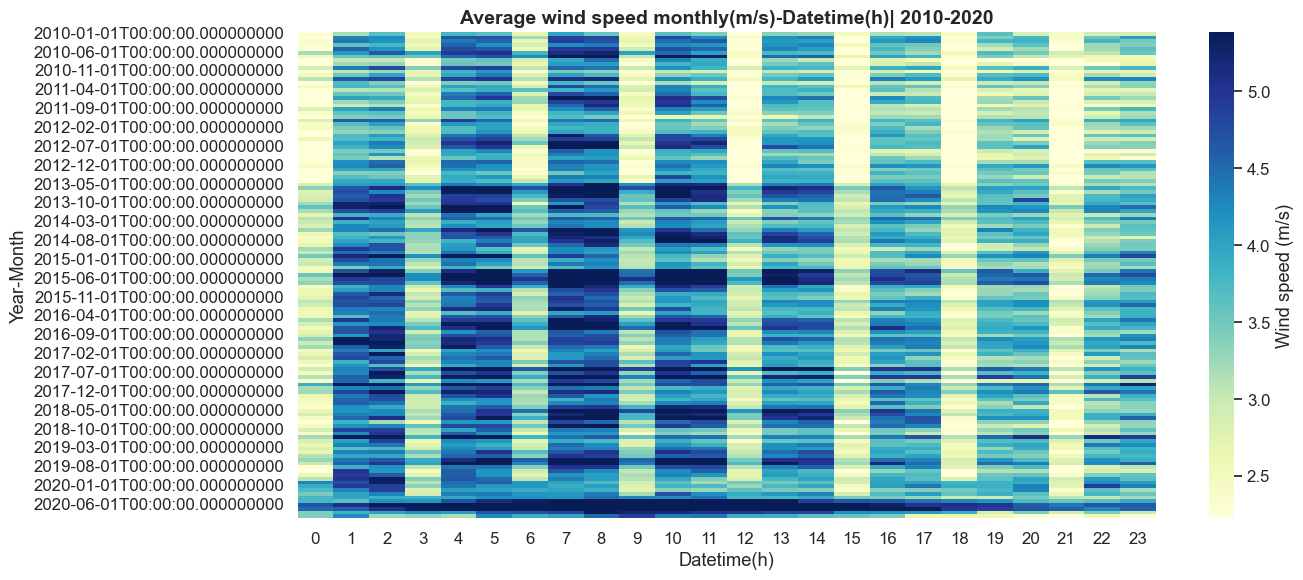

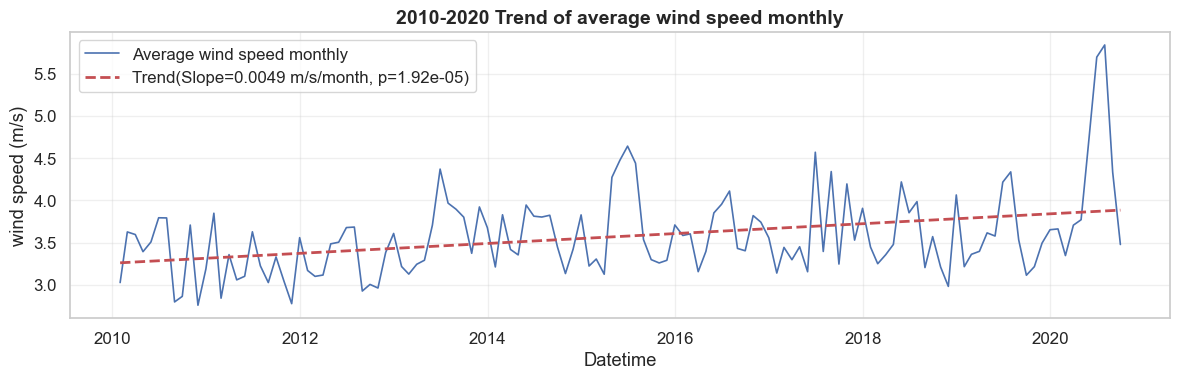


—— 报告说明 ——
1) 仅保留风向/风速质控码 ∈ {0,1,4,5,9}。
2) 剔除风速缺失码 9999。
3) 按 POS 66–69 换算风速单位：原始值/10 → m/s。
4) 保留风速类型 N/H/R/T。
5) 时间范围限定为 2010–2020。
6) 绘制了“月平均风速–观测时刻”热图与趋势分析。


In [75]:
# 2. Wind speed in Shenzhen from 2010 to 2020

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 设置中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

# ============= 读取原始 CSV =============
file_path = r"D:\ProgramData\anaconda3\2281305.csv"
df = pd.read_csv(file_path, low_memory=False)
print("原始数据行数：", len(df))
print("原始列名：", df.columns.tolist())

# ============= 查找并解析时间列 =============
# 常见列名如 DATE, DATE_TIME, DATEUTC 等
time_col = None
for c in df.columns:
    if "DATE" in c.upper():
        time_col = c
        break


df["datetime"] = pd.to_datetime(df[time_col], errors="coerce")
df = df.dropna(subset=["datetime"]).copy()

# ============= 解析 WND 字段（POS 61–70） =============
if "WND" not in df.columns:
    raise ValueError("未找到 'WND' 列，请确认此文件为 ISD 格式数据。")

# WND 格式一般为 "ddd, q, t, ssss, qc"
wind = df["WND"].astype(str).str.split(",", expand=True)
if wind.shape[1] < 5:
    raise ValueError("WND 字段格式不完整，应包含 5 个部分。")

wind.columns = ["dir", "dir_qc", "type", "spd", "spd_qc"]

# 转换数据类型
for col in ["dir", "dir_qc", "spd", "spd_qc"]:
    wind[col] = pd.to_numeric(wind[col], errors="coerce")
wind["type"] = wind["type"].astype(str).str.strip()

# 合并回主表
df = pd.concat([df[["datetime"]], wind], axis=1)

# ============= 按时间范围筛选（2010–2020） =============
df = df[(df["datetime"].dt.year >= 2010) & (df["datetime"].dt.year <= 2020)].copy()

# ============= 按 POS 61–70 质量控制 =============
# QC码 0,1,4,5,9 为通过检查或来源可靠
valid_qc = {0,1,4,5,9}
df = df[df["spd_qc"].isin(valid_qc) & df["dir_qc"].isin(valid_qc)]

# 剔除缺失风速（9999 表示缺失）
df = df[df["spd"].notna() & (df["spd"] != 9999)]

# 风速单位换算：除以10，得到 m/s
df["wind_speed_ms"] = df["spd"] / 10.0

# 风速类型：保留 N/H/R/T（Normal, 5min, 60min, 10min 平均）
valid_types = {"N", "H", "R", "T"}
df = df[df["type"].isin(valid_types)]

# ============= 提取时间信息 =============
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour

print("清洗后记录数：", len(df))
print(df.head(3))

# ============= ① 热图：月平均风速 vs 小时 =============
df["ym"] = df["datetime"].dt.to_period("M").dt.to_timestamp()
pivot = (
    df.groupby(["ym","hour"], as_index=False)["wind_speed_ms"]
      .mean()
      .pivot(index="ym", columns="hour", values="wind_speed_ms")
      .sort_index()
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap="YlGnBu",
    cbar_kws={"label":"Wind speed (m/s)"},
    vmin=np.nanpercentile(pivot.values, 5),
    vmax=np.nanpercentile(pivot.values, 95)
)
plt.title("Average wind speed monthly(m/s)-Datetime(h)| 2010-2020", fontsize=14, fontweight="bold")
plt.xlabel("Datetime(h)")
plt.ylabel("Year-Month")
plt.tight_layout()
plt.show()

# ============= ② 月平均风速时间序列 + 线性趋势 =============
monthly = df.groupby(pd.Grouper(key="datetime", freq="M"))["wind_speed_ms"].mean()

plt.figure(figsize=(12,4))
plt.plot(monthly.index, monthly.values, label="Average wind speed monthly", lw=1.2)

# 线性趋势拟合
x = np.arange(len(monthly))
y = monthly.values
mask = ~np.isnan(y)
slope, intercept, r, p, se = stats.linregress(x[mask], y[mask])
trend = intercept + slope * x
plt.plot(monthly.index, trend, "r--", lw=2, label=f"Trend(Slope={slope:.4f} m/s/month, p={p:.3g})")

plt.title("2010-2020 Trend of average wind speed monthly", fontsize=14, fontweight="bold")
plt.ylabel("wind speed (m/s)")
plt.xlabel("Datetime")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============= 输出报告说明 =============
print("\n—— 报告说明 ——")
print("1) 仅保留风向/风速质控码 ∈ {0,1,4,5,9}。")
print("2) 剔除风速缺失码 9999。")
print("3) 按 POS 66–69 换算风速单位：原始值/10 → m/s。")
print("4) 保留风速类型 N/H/R/T。")
print("5) 时间范围限定为 2010–2020。")
print("6) 绘制了“月平均风速–观测时刻”热图与趋势分析。")


=== 数据基本信息 ===
数据形状: (1759, 7)
列名: ['Location', 'Experimental year', 'Soil pH', 'Soil Olsen-P (mg kg-1)', 'Crop types', 'P fertilizer type', 'lnRR']

原始数据量: 1759  |  剔除异常值后: 1676

分析 1：Location 与 lnRR（仅绘制样本量 Top-20）


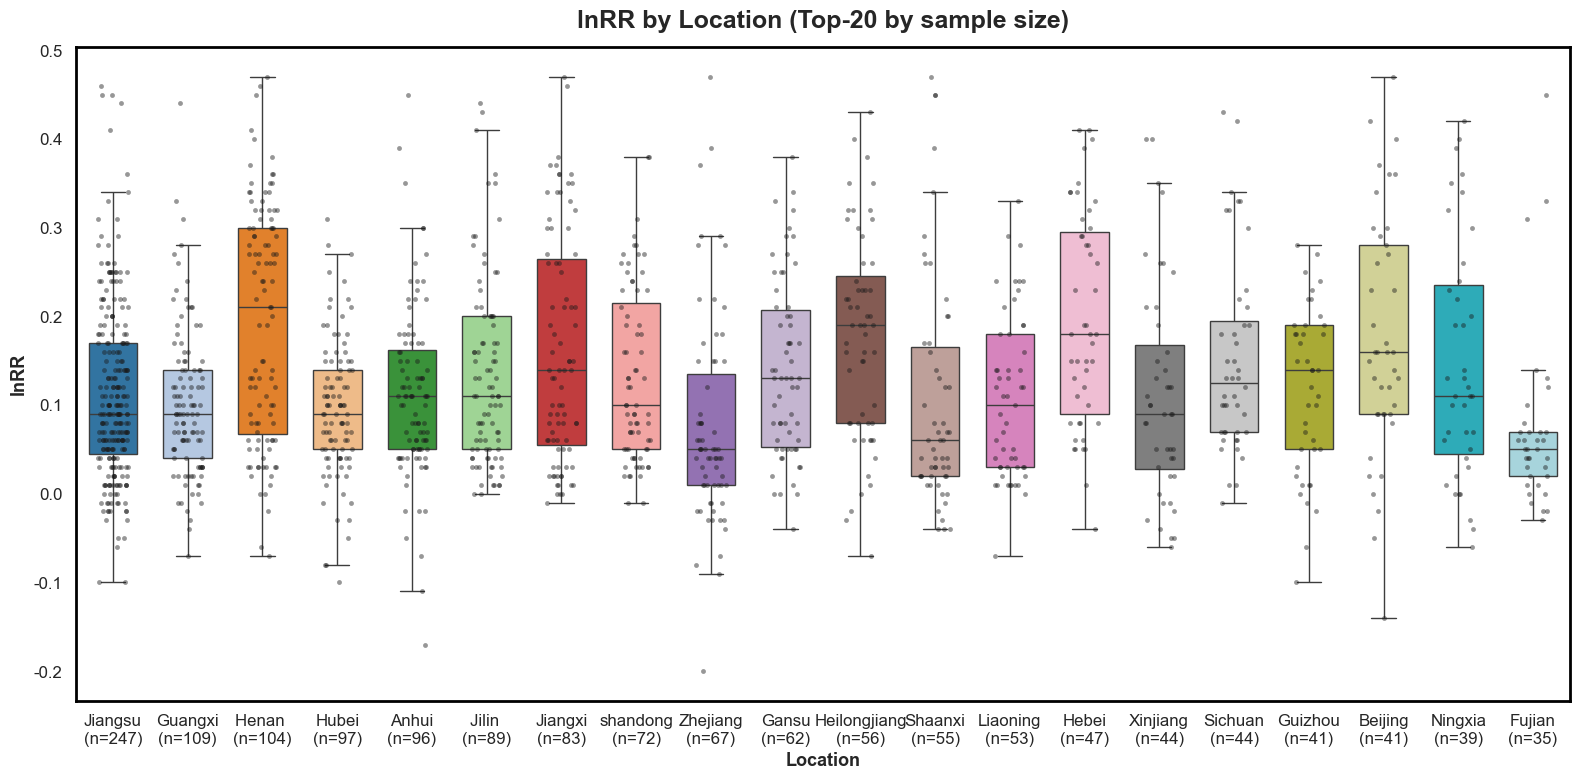


分析 2：Crop types 与 lnRR


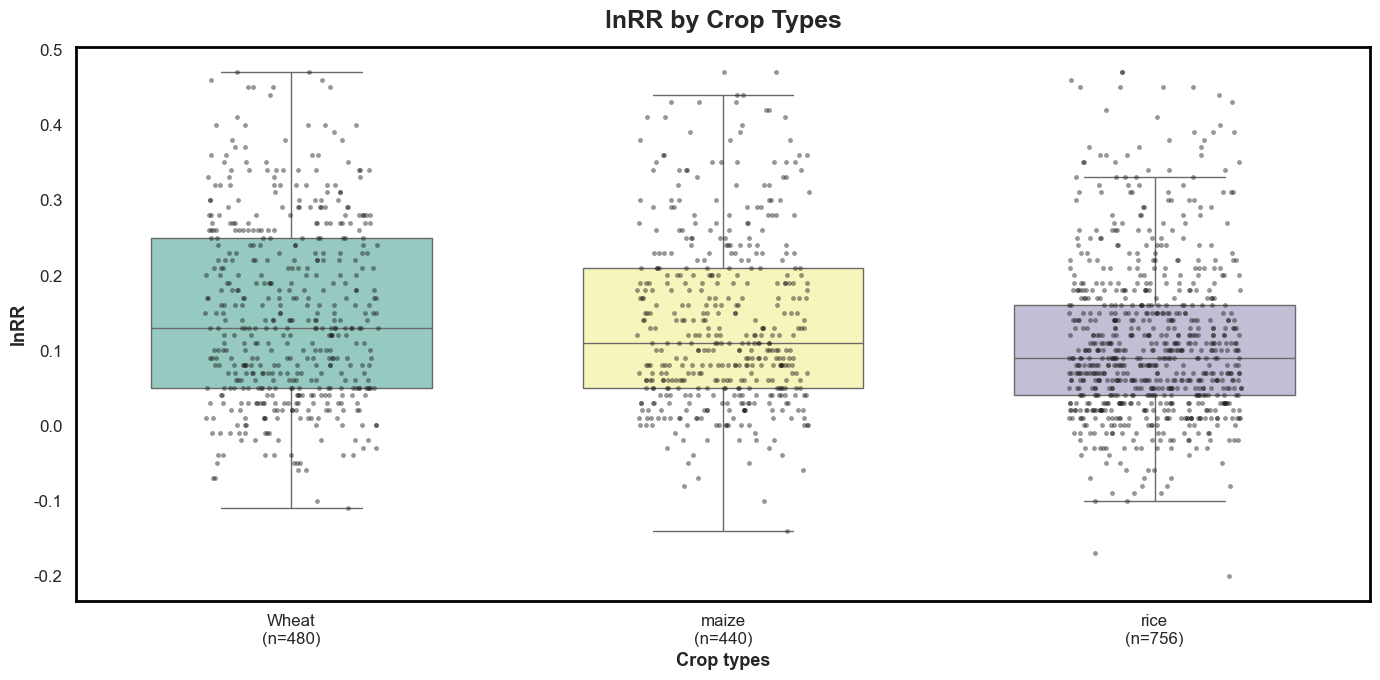


分析 3：P fertilizer type 与 lnRR


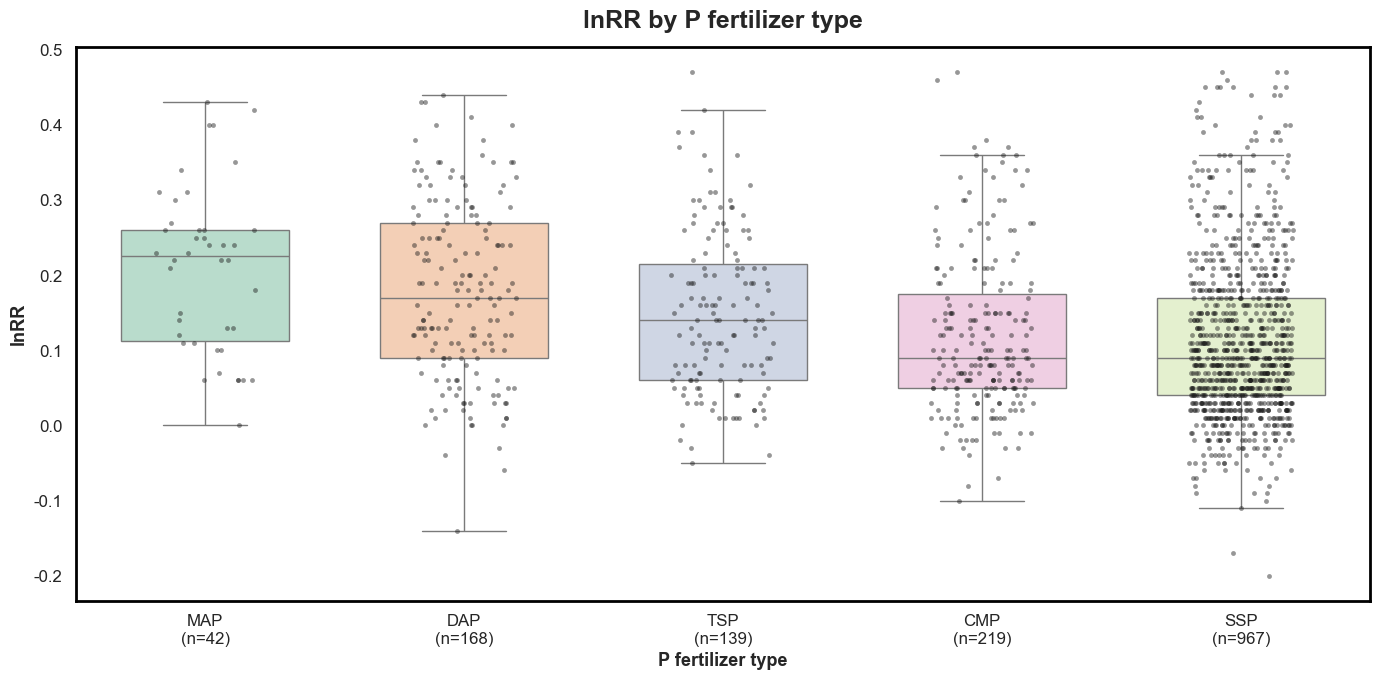


统计显著性检验（ANOVA）
        Location  ANOVA:  F=5.7701,  p=3.506e-20
      Crop_types  ANOVA:  F=21.5326,  p=5.846e-10
     P_fert_type  ANOVA:  F=21.4192,  p=3.285e-17


In [63]:
# 3. Explore a dataset

import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 中文字体的设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(context="notebook", style="white", font_scale=1.1)

# === 读取数据 ===
file_path = r"C:\Users\Administrator\.vscode\Ziyanliu.xlsx"

df = pd.read_excel(file_path)

print("=== 数据基本信息 ===")
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")

required_columns = ['lnRR', 'Location', 'Crop types', 'P fertilizer type']
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"缺少必要列：{missing}")

# === 3.1 处理 lnRR 的极端值（IQR） ===
Q1, Q3 = df['lnRR'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
cleaned = df[(df['lnRR'] >= lb) & (df['lnRR'] <= ub)].copy()
print(f"\n原始数据量: {len(df)}  |  剔除异常值后: {len(cleaned)}")

# === 解析作物与肥料列（不覆盖原始列） ===
def parse_crop(s):
    """从 Crop types 中提取作物名：取 '/' 前一段；无 '/' 则原样；空为 NaN"""
    if pd.isna(s): 
        return np.nan
    s = str(s).strip()
    return s.split('/')[0].strip() if '/' in s else s

_split_pattern = re.compile(r'[/,;|]')

def parse_fert(s):
    """从 P fertilizer type 中解析肥料名：按 / , ; | 分隔，取**最后一段**；无分隔符则原样"""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    parts = [p.strip() for p in _split_pattern.split(s) if p.strip()]
    return parts[-1] if parts else s

cleaned['Crop_types']  = cleaned['Crop types'].apply(parse_crop)
cleaned['P_fert_type'] = cleaned['P fertilizer type'].apply(parse_fert)

# === 修改后的画图函数：返回 ax 对象以便添加边框 ===
def nice_boxplot(data, group_col, value_col='lnRR', 
                 title='', xlabel='', palette='Set2',
                 order_by='median',  # 'median' or 'count'
                 min_n=2, top_k=None, figsize=(14, 7)):
    """
    data: DataFrame
    group_col: 分组列名
    value_col: 数值列（lnRR）
    order_by: 按 'median' 或 'count' 排序
    min_n: 每组最小样本量（小于则剔除）
    top_k: 仅绘制样本量排名前 top_k 的类别（防止过多类别挤在一张图）
    """
    tmp = (data
           .dropna(subset=[group_col, value_col])
           .groupby(group_col)[value_col]
           .agg(count='count', median='median', mean='mean')
           .reset_index())

    # 过滤样本太少的组
    tmp = tmp[tmp['count'] >= min_n].copy()
    if not len(tmp):
        print(f"[跳过] {group_col} 全部组的样本数都 < {min_n}")
        return None

    # 顺序
    if order_by == 'median':
        tmp = tmp.sort_values('median', ascending=False)
    else:
        tmp = tmp.sort_values('count', ascending=False)

    # 只保留前 top_k 个类别（可防止 X 轴太挤）
    if top_k is not None and len(tmp) > top_k:
        tmp = tmp.head(top_k)

    order = tmp[group_col].tolist()

    # 构造 "标签\n(n=样本量)" 的 x 轴刻度
    label_map = {r[group_col]: f"{r[group_col]}\n(n={int(r['count'])})" for _, r in tmp.iterrows()}
    data_ = data[data[group_col].isin(order)].copy()

    # 画图
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(
        data=data_, x=group_col, y=value_col,
        order=order, palette=palette,
        showfliers=False,  # 去掉离群点（散点层会展示）
        width=0.65,
        ax=ax
    )
    sns.stripplot(
        data=data_, x=group_col, y=value_col,
        order=order, color='k', size=3.5, alpha=0.45,
        jitter=0.2,
        ax=ax
    )

    # 美化
    ax.set_title(title, fontsize=18, fontweight='bold', pad=14)
    ax.set_xlabel(xlabel if xlabel else group_col, fontsize=13, fontweight='bold')
    ax.set_ylabel(value_col, fontsize=13, fontweight='bold')

    # 用"名称 + n"替换刻度标签
    ax.set_xticklabels([label_map.get(g, str(g)) for g in order], rotation=0, ha='center')

    sns.despine(left=True, bottom=False)
    
    # 添加加粗的全外框
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(2.0)
        ax.spines[side].set_color('black')
    
    plt.tight_layout()
    plt.show()
    
    return ax

# === 3.2&3.3 ===
# === 1) Location 与 lnRR ===
print("\n" + "="*60)
print("分析 1：Location 与 lnRR（仅绘制样本量 Top-20）")
print("="*60)

ax1 = nice_boxplot(
    cleaned, group_col='Location', value_col='lnRR',
    title='lnRR by Location (Top-20 by sample size)',
    xlabel='Location',
    palette='tab20',
    order_by='count',
    min_n=2,
    top_k=20,           # 地点太多，限制前 20 个
    figsize=(16, 8)
)

# === 2) Crop types 与 lnRR ===
print("\n" + "="*60)
print("分析 2：Crop types 与 lnRR")
print("="*60)

ax2 = nice_boxplot(
    cleaned, group_col='Crop_types', value_col='lnRR',
    title='lnRR by Crop Types',
    xlabel='Crop types',
    palette='Set3',
    order_by='median',
    min_n=2,
    top_k=None,         # 作物类目不太多
    figsize=(14, 7)
)

# === 3) P fertilizer type 与 lnRR ===
print("\n" + "="*60)
print("分析 3：P fertilizer type 与 lnRR")
print("="*60)

ax3 = nice_boxplot(
    cleaned, group_col='P_fert_type', value_col='lnRR',
    title='lnRR by P fertilizer type',
    xlabel='P fertilizer type',
    palette='Pastel2',
    order_by='median',
    min_n=2,
    top_k=None,
    figsize=(14, 7)
)

# === 统计显著性检验（ANOVA）===
print("\n" + "="*60)
print("统计显著性检验（ANOVA）")
print("="*60)

def anova_on_col(df_, col, val='lnRR', min_n=2):
    groups = [g[val].values for _, g in df_.groupby(col) if len(g) >= min_n]
    if len(groups) >= 2:
        f, p = stats.f_oneway(*groups)
        print(f"{col:>16}  ANOVA:  F={f:.4f},  p={p:.4g}")
    else:
        print(f"{col:>16}  组数不足，跳过 ANOVA")

anova_on_col(cleaned, 'Location')
anova_on_col(cleaned, 'Crop_types')
anova_on_col(cleaned, 'P_fert_type')